In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("C:/Users/ASUS/Desktop/SYNTECXHUB PROJECT/Project 2 On Python/data-export (1).csv")

In [48]:
# Make the first row the column headers
df.columns = df.iloc[0]

# Remove the first row and reset the index
df = df.drop(index=0).reset_index(drop=True)

# Rename the columns
df.columns = [
    "Channel Group",
    "Date_Hour",
    "User",
    "Session",
    "Engaged Session",
    "Average engagement time per session",
    "Engaged sessions per user",
    "Events per session",
    "Engagement rate",
    "Event count"
]
df.head()

ValueError: Length mismatch: Expected axis has 11 elements, new values have 10 elements

In [7]:
df["Date_Hour"]=pd.to_datetime(df["Date_Hour"],format="%Y%m%d%H",errors='coerce')
numeric_cols=df.columns.drop(["Channel Group","Date_Hour"])
df[numeric_cols]=df[numeric_cols].apply(pd.to_numeric,errors='coerce')
df["Hour"]=df['Date_Hour'].dt.hour

In [10]:
numeric_cols=df.columns.drop(["Channel Group","Date_Hour"])
df[numeric_cols]=df[numeric_cols].apply(pd.to_numeric,errors='coerce')
df['Hour']=df["Date_Hour"].dt.hour

In [16]:
import seaborn as sns
sns.set(style='whitegrid')

# # SESSIONS AND USER OVER TIME


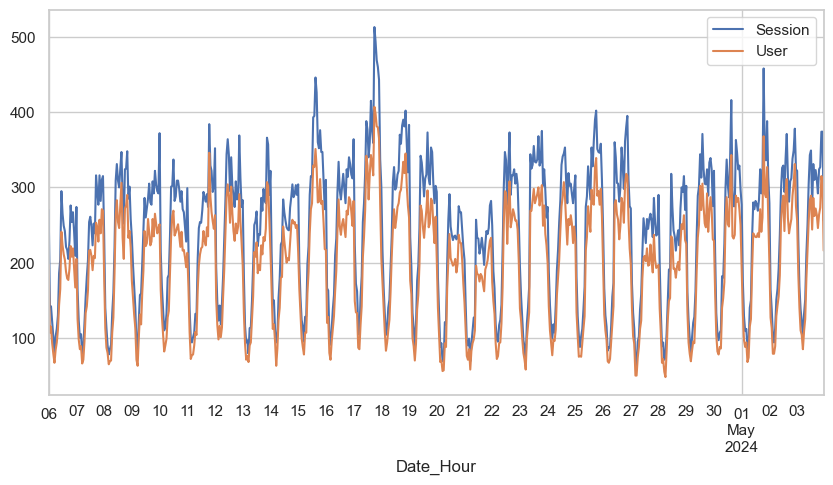

In [29]:
plt.figure(figsize=(10,5))
df.groupby("Date_Hour")[["Session","User"]].sum().plot(ax=plt.gca())
plt.show()

## TOTAL USER BY CHANNEL

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21096\280468328.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


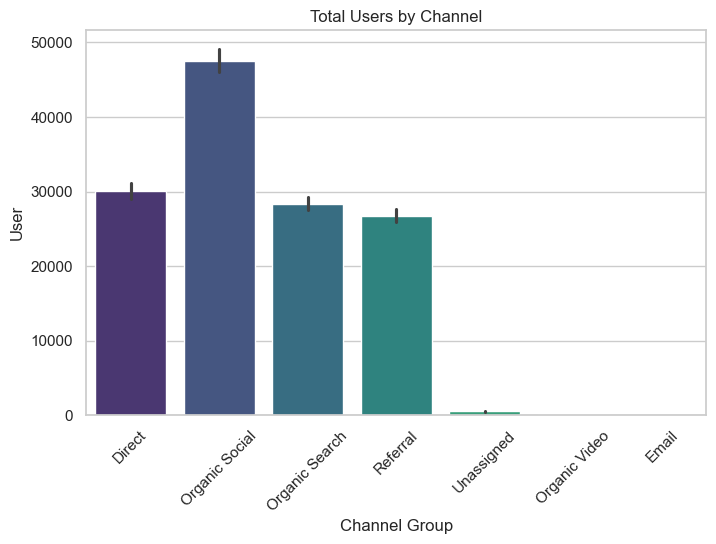

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Channel Group",
    y="User",
    estimator=np.sum,
    palette="viridis"
)

plt.title("Total Users by Channel")
plt.xticks(rotation=45)
plt.show()

## Average Engagement Time By Channel

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21096\142385087.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


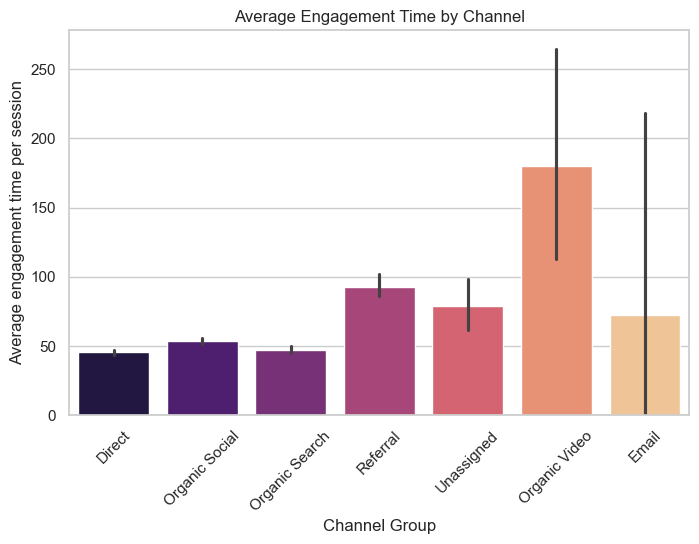

In [33]:

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Channel Group",
    y="Average engagement time per session",
    estimator=np.mean,
    palette="magma"
)

plt.title("Average Engagement Time by Channel")
plt.xticks(rotation=45)
plt.show()

## Engagement Rate Distribution By Channel

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21096\1372625058.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


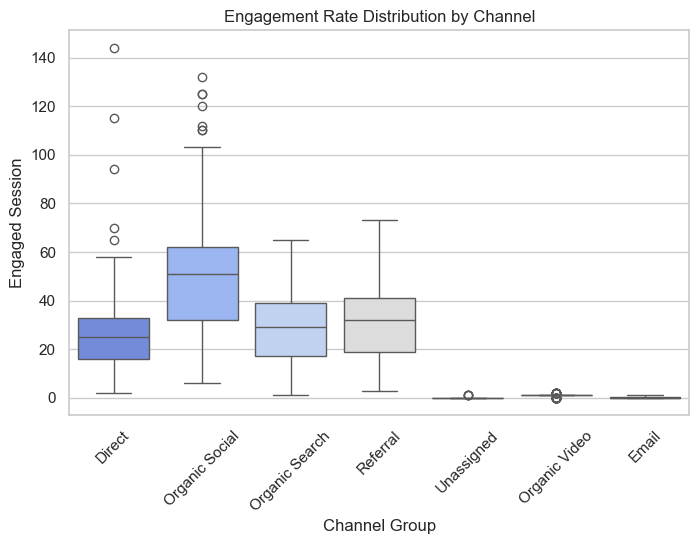

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Channel Group",
    y="Engaged Session",
    palette="coolwarm"
)

plt.title("Engagement Rate Distribution by Channel")
plt.xticks(rotation=45)
plt.show()

## Engaged vs Non Engaged Sessions

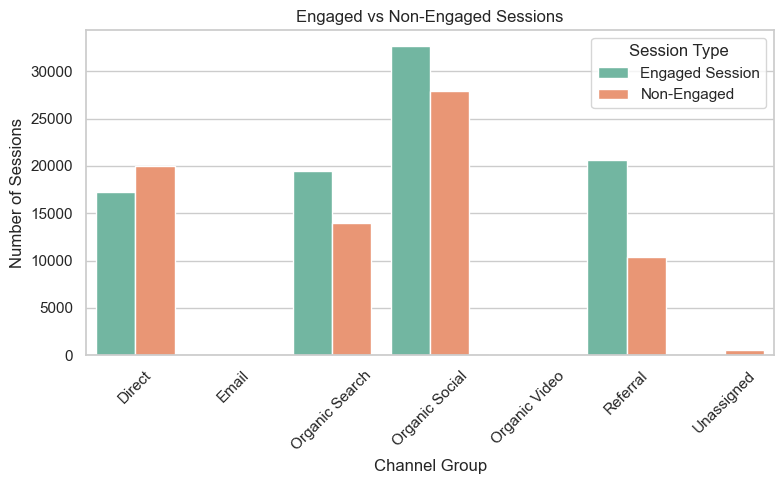

In [41]:
# Group data by Channel Group
session_df = (
    df.groupby("Channel Group")[["Session", "Engaged Session"]]
      .sum()
      .reset_index()
)

# Calculate Non-Engaged Sessions
session_df["Non-Engaged"] = (
    session_df["Session"] - session_df["Engaged Session"]
)

# Convert data to long format
session_df_melted = session_df.melt(
    id_vars="Channel Group",
    value_vars=["Engaged Session", "Non-Engaged"],
    var_name="Session Type",
    value_name="Count"
)

# Plot
plt.figure(figsize=(8, 5))

sns.barplot(
    data=session_df_melted,
    x="Channel Group",
    y="Count",
    hue="Session Type",
    palette="Set2"
)

plt.title("Engaged vs Non-Engaged Sessions")
plt.xlabel("Channel Group")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Traffic By Hour And Channel

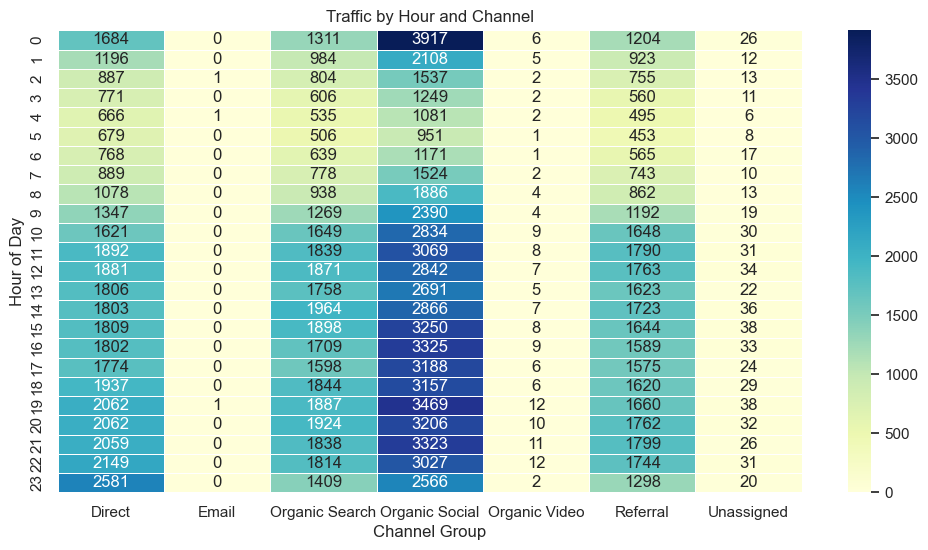

In [46]:
# Create pivot table
heatmap_data = (
    df.groupby(["Hour", "Channel Group"])["Session"]
      .sum()
      .unstack()
      .fillna(0)
)

# Plot heatmap
plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    annot=True,
    fmt=".0f"
)

plt.title("Traffic by Hour and Channel")
plt.xlabel("Channel Group")
plt.ylabel("Hour of Day")

plt.show()

## Engagement Rate VS Session Over Time

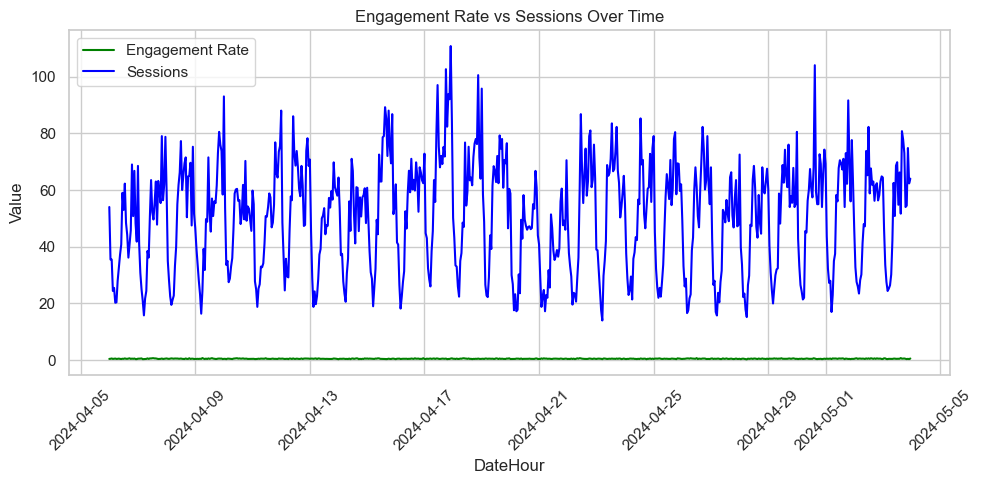

In [44]:

# Group data by DateHour and calculate the mean
df_plot = (
    df.groupby("Date_Hour")[["Engagement rate", "Session"]]
      .mean()
      .reset_index()
)

# Create figure
plt.figure(figsize=(10, 5))

# Plot Engagement Rate
plt.plot(
    df_plot["Date_Hour"],
    df_plot["Engagement rate"],
    label="Engagement Rate",
    color="green"
)

# Plot Sessions
plt.plot(
    df_plot["Date_Hour"],
    df_plot["Session"],
    label="Sessions",
    color="blue"
)

# Add title and labels
plt.title("Engagement Rate vs Sessions Over Time")
plt.xlabel("DateHour")
plt.ylabel("Value")

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Show legend and grid
plt.legend()
plt.grid(True)

# Adjust layout and display
plt.tight_layout()
plt.show()